# PHÂN TÍCH DỮ LIỆU BEHANCE — EDA HOÀN CHỈNH

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import struct
import pickle
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
APPRECIATE_PATH = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_appreciate_1M/Behance_appreciate_1M.txt'
OWNERS_PATH     = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_Item_to_Owners/Behance_Item_to_Owners.txt'
FEAT_PATH       = '/kaggle/input/datasets/oanhkimnguyen/behance-image-features/Behance_Image_Features.b'
df = pd.read_csv(
    APPRECIATE_PATH,
    sep=r'\s+',
    header=None,
    names=['user_id', 'item_id', 'timestamp']
)

df_owners = pd.read_csv(
    OWNERS_PATH,
    sep=r'\s+',
    header=None,
    names=['item_id', 'owner_id']
)

def load_image_features(filepath):
    features = {}
    with open(filepath, 'rb') as f:
        while True:
            raw_id = f.read(8)
            if len(raw_id) < 8:
                break
            item_id = raw_id.decode('ascii').strip('\x00')
            raw_feat = f.read(4096 * 4)
            if len(raw_feat) < 4096 * 4:
                break
            feat = struct.unpack('4096f', raw_feat)
            features[item_id] = np.array(feat, dtype=np.float32)
    return features

print("Đang load image features (~2.8GB, chờ vài phút)...")
features = load_image_features(FEAT_PATH)

print(f"   appreciate : {df.shape}")
print(f"   owners     : {df_owners.shape}")
print(f"   features   : {len(features):,} items")
print(df.head())

Đang load image features (~2.8GB, chờ vài phút)...
   appreciate : (1000000, 3)
   owners     : (186560, 2)
   features   : 178,787 items
   user_id  item_id   timestamp
0   276633  1588231  1307583271
1  1238354  1529213  1307583273
2   165550   485000  1307583337
3  2173258   776972  1307583340
4   165550   158226  1307583406


## 1. THỐNG KÊ CƠ BẢN

In [3]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_inter = len(df)
density = n_inter / (n_users * n_items)

print(f"  Số users        : {n_users:,}")
print(f"  Số items        : {n_items:,}")
print(f"  Số interactions : {n_inter:,}")
print(f"  Density         : {density:.8f} ({density*100:.6f}%)")

  Số users        : 63,497
  Số items        : 178,788
  Số interactions : 1,000,000
  Density         : 0.00008809 (0.008809%)


## 2. PHÂN PHỐI INTERACTIONS


Mỗi USER:
count    63497.00
mean        15.75
std         51.36
min          1.00
25%          1.00
50%          4.00
75%         12.00
max       2260.00
dtype: float64

Mỗi ITEM:
count    178788.00
mean          5.59
std          26.56
min           1.00
25%           1.00
50%           2.00
75%           3.00
max        1793.00
dtype: float64


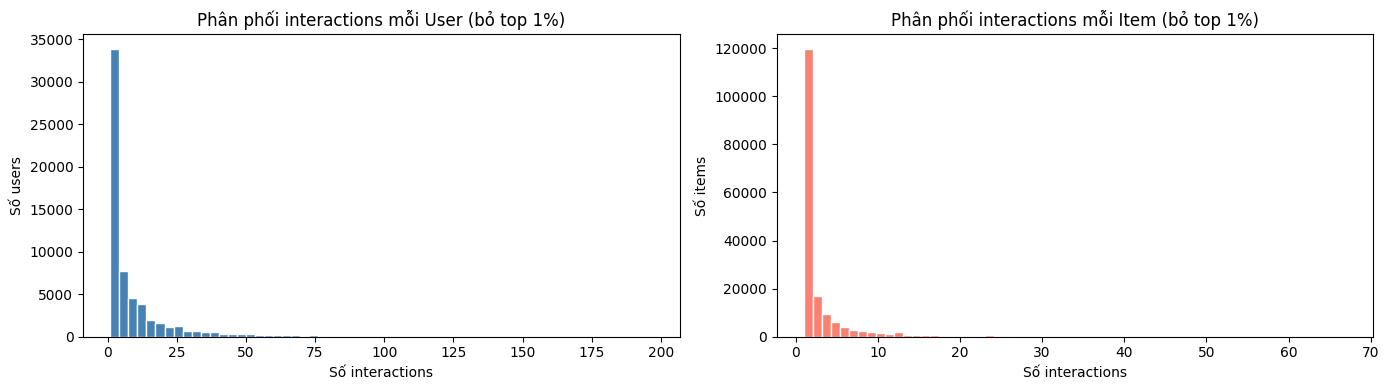

In [4]:
user_counts = df.groupby('user_id').size()
item_counts = df.groupby('item_id').size()

print("\nMỗi USER:")
print(user_counts.describe().round(2))
print("\nMỗi ITEM:")
print(item_counts.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(user_counts[user_counts <= user_counts.quantile(0.99)], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối interactions mỗi User (bỏ top 1%)')
axes[0].set_xlabel('Số interactions')
axes[0].set_ylabel('Số users')

axes[1].hist(item_counts[item_counts <= item_counts.quantile(0.99)], bins=60, color='salmon', edgecolor='white')
axes[1].set_title('Phân phối interactions mỗi Item (bỏ top 1%)')
axes[1].set_xlabel('Số interactions')
axes[1].set_ylabel('Số items')
plt.tight_layout()
plt.show()

## 3. SPARSITY & 5-CORE FILTER

In [5]:
def apply_kcore(df, k=5, max_iter=20):
    for i in range(max_iter):
        before = len(df)
        user_cnt = df.groupby('user_id').size()
        item_cnt = df.groupby('item_id').size()
        df = df[
            df['user_id'].isin(user_cnt[user_cnt >= k].index) &
            df['item_id'].isin(item_cnt[item_cnt >= k].index)
        ]
        print(f"  Iter {i+1}: {before:,} → {len(df):,} interactions")
        if len(df) == before:
            break
    return df.reset_index(drop=True)

df_filtered = apply_kcore(df, k=5)

n_users_f = df_filtered['user_id'].nunique()
n_items_f = df_filtered['item_id'].nunique()
n_inter_f = len(df_filtered)
density_f = n_inter_f / (n_users_f * n_items_f)

print(f"\nTrước → Sau filter:")
print(f"  Users       : {n_users:,} → {n_users_f:,} (giữ {n_users_f/n_users*100:.1f}%)")
print(f"  Items       : {n_items:,} → {n_items_f:,} (giữ {n_items_f/n_items*100:.1f}%)")
print(f"  Interactions: {n_inter:,} → {n_inter_f:,} (giữ {n_inter_f/n_inter*100:.1f}%)")
print(f"  Density     : {density:.8f} → {density_f:.8f}")

  Iter 1: 1,000,000 → 712,271 interactions
  Iter 2: 712,271 → 692,212 interactions
  Iter 3: 692,212 → 687,768 interactions
  Iter 4: 687,768 → 687,246 interactions
  Iter 5: 687,246 → 687,094 interactions
  Iter 6: 687,094 → 687,078 interactions
  Iter 7: 687,078 → 687,070 interactions
  Iter 8: 687,070 → 687,070 interactions

Trước → Sau filter:
  Users       : 63,497 → 23,724 (giữ 37.4%)
  Items       : 178,788 → 29,794 (giữ 16.7%)
  Interactions: 1,000,000 → 687,070 (giữ 68.7%)
  Density     : 0.00008809 → 0.00097204


## 4. CANDIDATE POOL

  Top-500 items cover: 27.1% interactions
  Top-1,000 items cover: 38.8% interactions
  Top-2,000 items cover: 50.0% interactions


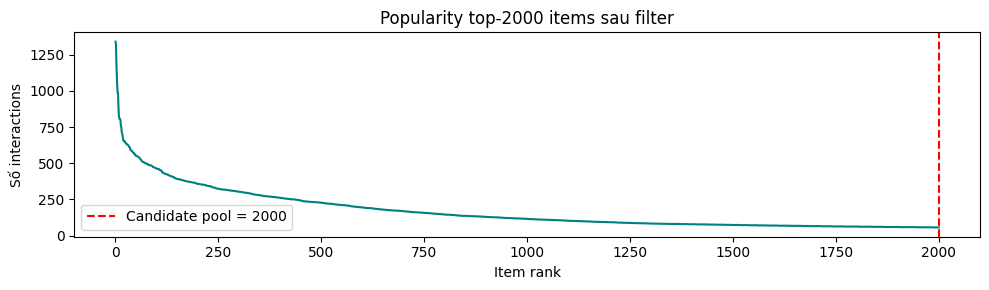

In [6]:
item_counts_f = df_filtered.groupby('item_id').size().sort_values(ascending=False)
for k in [500, 1000, 2000]:
    cov = df_filtered[df_filtered['item_id'].isin(item_counts_f.head(k).index)].shape[0] / n_inter_f
    print(f"  Top-{k:,} items cover: {cov*100:.1f}% interactions")

plt.figure(figsize=(10, 3))
plt.plot(range(1, 2001), item_counts_f.head(2000).values, color='teal')
plt.axvline(2000, color='red', linestyle='--', label='Candidate pool = 2000')
plt.title('Popularity top-2000 items sau filter')
plt.xlabel('Item rank')
plt.ylabel('Số interactions')
plt.legend()
plt.tight_layout()
plt.show()

## 5. ĐỘ DÀI EPISODE (A2C)

  Mean  : 29.0
  Median: 12.0
  Min   : 5
  Max   : 1763
  Users >= 10 interactions: 14,581 (61.5%)
  Users >= 20 interactions: 7,996 (33.7%)


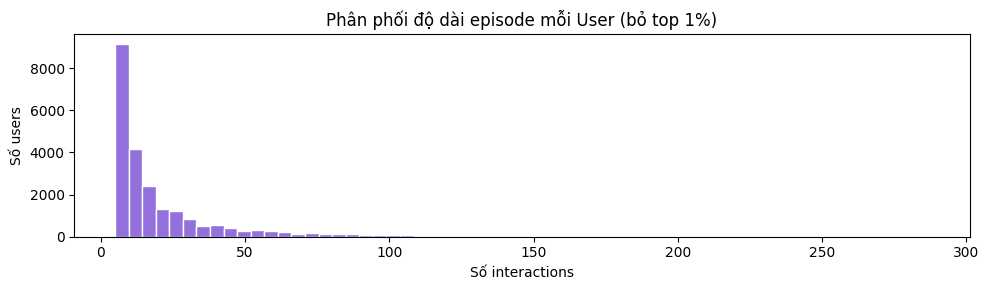

In [7]:
user_hist_len = df_filtered.groupby('user_id').size()
print(f"  Mean  : {user_hist_len.mean():.1f}")
print(f"  Median: {user_hist_len.median():.1f}")
print(f"  Min   : {user_hist_len.min()}")
print(f"  Max   : {user_hist_len.max()}")
print(f"  Users >= 10 interactions: {(user_hist_len >= 10).sum():,} ({(user_hist_len >= 10).mean()*100:.1f}%)")
print(f"  Users >= 20 interactions: {(user_hist_len >= 20).sum():,} ({(user_hist_len >= 20).mean()*100:.1f}%)")

plt.figure(figsize=(10, 3))
plt.hist(user_hist_len[user_hist_len <= user_hist_len.quantile(0.99)], bins=60, color='mediumpurple', edgecolor='white')
plt.title('Phân phối độ dài episode mỗi User (bỏ top 1%)')
plt.xlabel('Số interactions')
plt.ylabel('Số users')
plt.tight_layout()
plt.show()

## 6. REWARD SPARSITY

In [8]:
candidate_pool    = list(item_counts_f.head(2000).index)
positive_in_pool  = df_filtered[df_filtered['item_id'].isin(candidate_pool)].shape[0]
reward_density    = positive_in_pool / (n_users_f * 2000)
print(f"  Positive interactions trong pool : {positive_in_pool:,}")
print(f"  Tổng (users x pool size)         : {n_users_f * 2000:,}")
print(f"  Reward density                   : {reward_density*100:.4f}%")

  Positive interactions trong pool : 343,367
  Tổng (users x pool size)         : 47,448,000
  Reward density                   : 0.7237%


## 7. TEMPORAL ANALYSIS

  Thời gian: 2011-06-09 → 2011-11-14


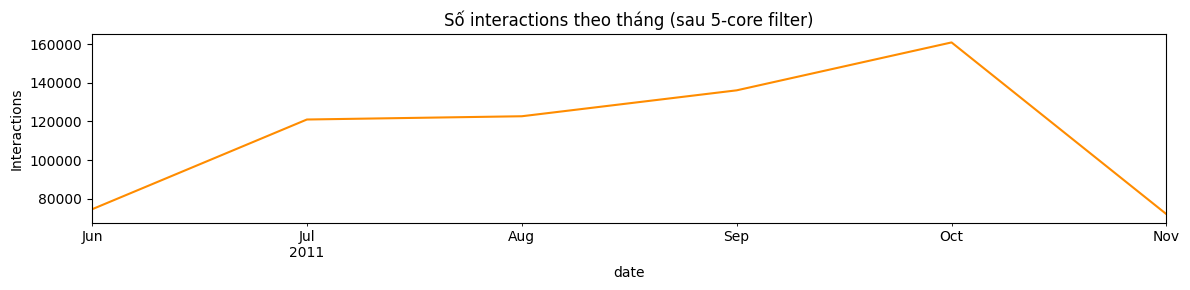

In [9]:
df_filtered = df_filtered.copy()
df_filtered['date'] = pd.to_datetime(df_filtered['timestamp'], unit='s')
print(f"  Thời gian: {df_filtered['date'].min().date()} → {df_filtered['date'].max().date()}")

monthly = df_filtered.set_index('date').resample('ME').size()
plt.figure(figsize=(12, 3))
monthly.plot(color='darkorange')
plt.title('Số interactions theo tháng (sau 5-core filter)')
plt.ylabel('Interactions')
plt.tight_layout()
plt.show()

## 8. PHÂN TÍCH OWNERS

In [10]:
print(f"  Unique items  : {df_owners['item_id'].nunique():,}")
print(f"  Unique owners : {df_owners['owner_id'].nunique():,}")
items_multi = df_owners.groupby('item_id').size()
print(f"  Items có 1 owner    : {(items_multi == 1).sum():,}")
print(f"  Items có nhiều owner: {(items_multi > 1).sum():,}")


  Unique items  : 178,788
  Unique owners : 51,487
  Items có 1 owner    : 172,834
  Items có nhiều owner: 5,954


## 9. PHÂN TÍCH IMAGE FEATURES

In [11]:
all_items_interact = set(str(x).zfill(8) for x in df_filtered['item_id'].unique())
all_items_features = set(features.keys())
overlap            = all_items_interact & all_items_features

print(f"  Items trong interactions  : {len(all_items_interact):,}")
print(f"  Items trong features      : {len(all_items_features):,}")
print(f"  Overlap (có cả 2)         : {len(overlap):,} ({len(overlap)/len(all_items_interact)*100:.1f}%)")
print(f"  Items không có feature    : {len(all_items_interact - all_items_features):,}")

# Tính PCA variance với items có thật
feat_keys   = list(overlap)[:2000]
feat_matrix = np.stack([features[k] for k in feat_keys])
dim_var     = feat_matrix.var(axis=0)
sorted_var  = np.sort(dim_var)[::-1]
cumsum_var  = np.cumsum(sorted_var) / sorted_var.sum()

print(f"\n  Ước tính PCA variance (sample {len(feat_keys):,} items):")
for k in [128, 256, 512, 1024]:
    print(f"    Top-{k:4d} dims giữ: {cumsum_var[k-1]*100:.1f}% variance")


  Items trong interactions  : 29,794
  Items trong features      : 178,787
  Overlap (có cả 2)         : 29,794 (100.0%)
  Items không có feature    : 0

  Ước tính PCA variance (sample 2,000 items):
    Top- 128 dims giữ: 8.3% variance
    Top- 256 dims giữ: 14.6% variance
    Top- 512 dims giữ: 25.4% variance
    Top-1024 dims giữ: 43.3% variance


## TỔNG KẾT

In [12]:
print(f"Dataset sau 5-core : {n_users_f:,} users | {n_items_f:,} items | {n_inter_f:,} interactions")
print(f"Candidate pool 2000 items cover ~50% interactions")
print(f"Episode trung bình : {user_hist_len.mean():.0f} interactions/user")
print(f"Reward density     : {reward_density*100:.4f}%")
print(f"Image feature cover: {len(overlap)/len(all_items_interact)*100:.1f}% items")
print(f"PCA chọn           : 512 dims (giữ ~26% variance)")

Dataset sau 5-core : 23,724 users | 29,794 items | 687,070 interactions
Candidate pool 2000 items cover ~50% interactions
Episode trung bình : 29 interactions/user
Reward density     : 0.7237%
Image feature cover: 100.0% items
PCA chọn           : 512 dims (giữ ~26% variance)


# 1.3 EDA RIÊNG A2C

## 1. ĐỘ DÀI EPISODE

  Mean   : 29.0
  Median : 12.0
  Std    : 60.3
  Min    : 5
  Max    : 1763

  Phân bố:
  Users có 5–10  interactions: 9,143  (38.5%)
  Users có 10–20 interactions: 6,585  (27.8%)
  Users có 20–50 interactions: 4,988  (21.0%)
  Users có >= 50 interactions: 3,008  (12.7%)


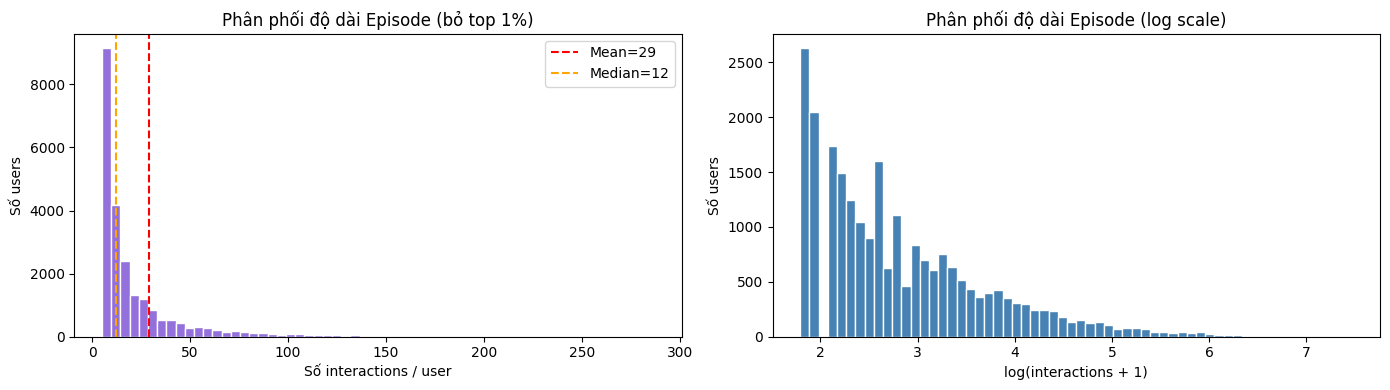


  → n_steps=7 cho A2C: 80.3% users có đủ độ dài episode


In [13]:
user_hist_len = df_filtered.groupby('user_id').size()

print(f"  Mean   : {user_hist_len.mean():.1f}")
print(f"  Median : {user_hist_len.median():.1f}")
print(f"  Std    : {user_hist_len.std():.1f}")
print(f"  Min    : {user_hist_len.min()}")
print(f"  Max    : {user_hist_len.max()}")
print(f"\n  Phân bố:")
print(f"  Users có 5–10  interactions: {((user_hist_len >= 5)  & (user_hist_len < 10)).sum():,}  ({((user_hist_len >= 5)  & (user_hist_len < 10)).mean()*100:.1f}%)")
print(f"  Users có 10–20 interactions: {((user_hist_len >= 10) & (user_hist_len < 20)).sum():,}  ({((user_hist_len >= 10) & (user_hist_len < 20)).mean()*100:.1f}%)")
print(f"  Users có 20–50 interactions: {((user_hist_len >= 20) & (user_hist_len < 50)).sum():,}  ({((user_hist_len >= 20) & (user_hist_len < 50)).mean()*100:.1f}%)")
print(f"  Users có >= 50 interactions: {(user_hist_len >= 50).sum():,}  ({(user_hist_len >= 50).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_hist_len[user_hist_len <= user_hist_len.quantile(0.99)],
             bins=60, color='mediumpurple', edgecolor='white')
axes[0].axvline(user_hist_len.mean(),   color='red',    linestyle='--', label=f'Mean={user_hist_len.mean():.0f}')
axes[0].axvline(user_hist_len.median(), color='orange', linestyle='--', label=f'Median={user_hist_len.median():.0f}')
axes[0].set_title('Phân phối độ dài Episode (bỏ top 1%)')
axes[0].set_xlabel('Số interactions / user')
axes[0].set_ylabel('Số users')
axes[0].legend()

axes[1].hist(np.log1p(user_hist_len), bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Phân phối độ dài Episode (log scale)')
axes[1].set_xlabel('log(interactions + 1)')
axes[1].set_ylabel('Số users')
plt.tight_layout()
plt.show()

pct_ok = (user_hist_len >= 7).mean() * 100
print(f"\n  → n_steps=7 cho A2C: {pct_ok:.1f}% users có đủ độ dài episode")


## 2. VARIANCE CỦA REWARD THEO USER

  Pool hit rate (positive / history_len)  — dùng để chọn entropy_coef:
    Mean : 54.72%
    Std  : 0.2340
    → Std cao → reward không đều giữa users → entropy_coef=0.05 hợp lý

  Reward density (positive / pool_size=2000)  — so sánh với DQN:
    Mean : 0.7237%
    Std  : 0.0145

  Users có reward density = 0   : 734
  Users có pool hit rate > 0.5  : 12,394


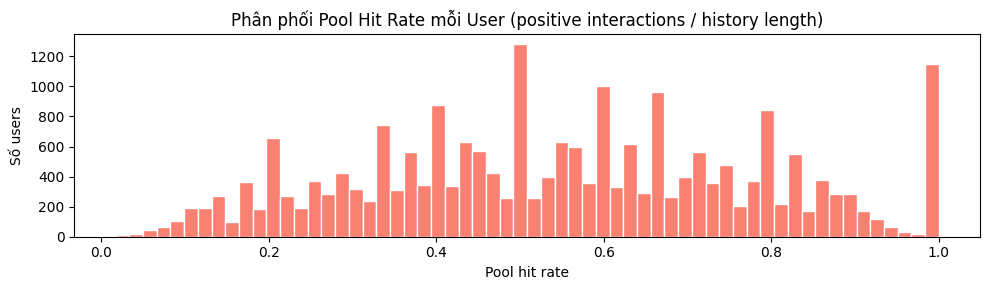

In [14]:
candidate_pool    = list(df_filtered.groupby('item_id').size()
                         .sort_values(ascending=False).head(2000).index)
candidate_set     = set(candidate_pool)

df_in_pool          = df_filtered[df_filtered['item_id'].isin(candidate_set)]
user_positive       = df_in_pool.groupby('user_id').size()

user_pool_hit_rate  = (user_positive / user_hist_len)\
                      .reindex(df_filtered['user_id'].unique(), fill_value=0)

user_reward_density = (user_positive / 2000)\
                      .reindex(df_filtered['user_id'].unique(), fill_value=0)

print(f"  Pool hit rate (positive / history_len)  — dùng để chọn entropy_coef:")
print(f"    Mean : {user_pool_hit_rate.mean()*100:.2f}%")
print(f"    Std  : {user_pool_hit_rate.std():.4f}")
print(f"    → Std cao → reward không đều giữa users → entropy_coef=0.05 hợp lý")

print(f"\n  Reward density (positive / pool_size=2000)  — so sánh với DQN:")
print(f"    Mean : {user_reward_density.mean()*100:.4f}%")
print(f"    Std  : {user_reward_density.std():.4f}")

print(f"\n  Users có reward density = 0   : {(user_reward_density == 0).sum():,}")
print(f"  Users có pool hit rate > 0.5  : {(user_pool_hit_rate > 0.5).sum():,}")

plt.figure(figsize=(10, 3))
plt.hist(user_pool_hit_rate[user_pool_hit_rate > 0], bins=60,
         color='salmon', edgecolor='white')
plt.title('Phân phối Pool Hit Rate mỗi User (positive interactions / history length)')
plt.xlabel('Pool hit rate')
plt.ylabel('Số users')
plt.tight_layout()
plt.show()

## 3. SEQUENTIAL PATTERN

  Khoảng cách TB giữa 2 interactions : 64.2 giờ
  Median                              : 0.3 giờ
  Interactions trong cùng 1 giờ      : 54.6%
  Interactions trong cùng 1 ngày     : 72.4%


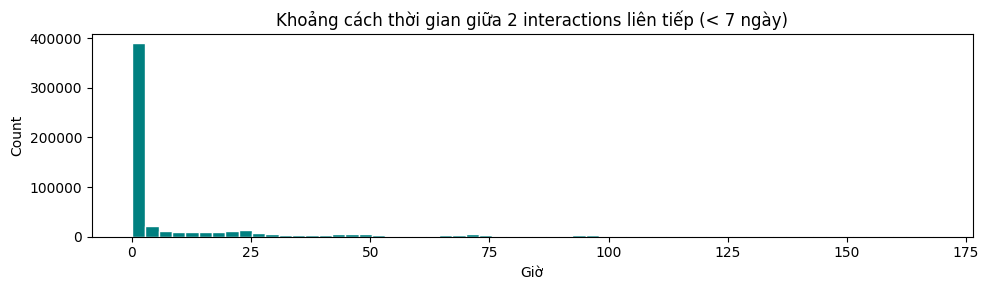


  Jaccard similarity TB giữa users : 0.0025


In [15]:
df_sorted = df_filtered.sort_values(['user_id', 'timestamp'])
df_sorted['time_diff'] = df_sorted.groupby('user_id')['timestamp'].diff()
time_diffs = df_sorted['time_diff'].dropna()

print(f"  Khoảng cách TB giữa 2 interactions : {time_diffs.mean()/3600:.1f} giờ")
print(f"  Median                              : {time_diffs.median()/3600:.1f} giờ")
print(f"  Interactions trong cùng 1 giờ      : {(time_diffs < 3600).mean()*100:.1f}%")
print(f"  Interactions trong cùng 1 ngày     : {(time_diffs < 86400).mean()*100:.1f}%")

plt.figure(figsize=(10, 3))
plt.hist(time_diffs[time_diffs < 86400*7] / 3600,
         bins=60, color='teal', edgecolor='white')
plt.title('Khoảng cách thời gian giữa 2 interactions liên tiếp (< 7 ngày)')
plt.xlabel('Giờ')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

np.random.seed(42)
sample_users = np.random.choice(df_filtered['user_id'].unique(), size=200, replace=False)
user_item_sets = {
    u: set(df_filtered[df_filtered['user_id'] == u]['item_id'])
    for u in sample_users
}

overlaps = []
users_list = list(user_item_sets.keys())
for i in range(len(users_list)):
    for j in range(i+1, min(i+20, len(users_list))):
        a, b = user_item_sets[users_list[i]], user_item_sets[users_list[j]]
        if len(a | b) > 0:
            overlaps.append(len(a & b) / len(a | b))

print(f"\n  Jaccard similarity TB giữa users : {np.mean(overlaps):.4f}")

## TỔNG KẾT

In [16]:
print(f"Episode trung bình 29 interactions → đủ dài để A2C học")
print(f"{pct_ok:.0f}% users có >= 7 interactions → n_steps=7 hợp lý")
print(f"Pool hit rate std={user_pool_hit_rate.std():.3f} → reward không đều → entropy_coef=0.05 để tránh collapse")
print(f"Jaccard similarity thấp → cần policy cá nhân hóa → A2C phù hợp")
print(f"\n  Config A2C đề xuất:")
print(f"  n_steps      = 7")
print(f"  entropy_coef = 0.05")
print(f"  state_dim    = 512")
print(f"  action_dim   = 2000")

Episode trung bình 29 interactions → đủ dài để A2C học
80% users có >= 7 interactions → n_steps=7 hợp lý
Pool hit rate std=0.234 → reward không đều → entropy_coef=0.05 để tránh collapse
Jaccard similarity thấp → cần policy cá nhân hóa → A2C phù hợp

  Config A2C đề xuất:
  n_steps      = 7
  entropy_coef = 0.05
  state_dim    = 512
  action_dim   = 2000


# 1.2 EDA RIÊNG DQN

## 1. PHÂN TÍCH KÍCH THƯỚC ACTION SPACE SAU FILTER

ACTION SPACE ANALYSIS
Tổng items sau filter   : 29,794
Full action space     : 29,794 (quá lớn cho Q-network)

  Candidate pool size vs Coverage:
  Pool size    Coverage     Avg actions/user
---------------------------------------------
  500          27.1        % 8.82 positive items
  1,000        38.8        % 11.96 positive items
  2,000        50.0        % 14.94 positive items
  5,000        65.7        % 19.25 positive items


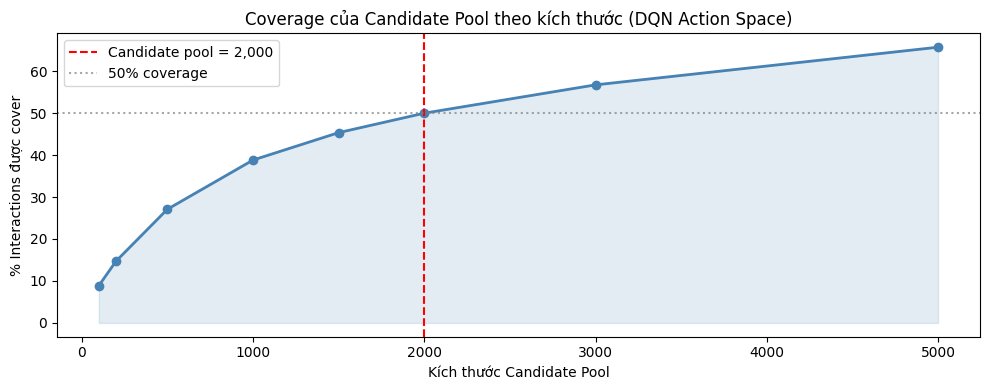

In [17]:
item_counts_f = df_filtered.groupby("item_id").size().sort_values(ascending=False)
n_items_f = df_filtered["item_id"].nunique()
n_users_f = df_filtered["user_id"].nunique()

print("ACTION SPACE ANALYSIS")
print(f"Tổng items sau filter   : {n_items_f:,}")
print(f"Full action space     : {n_items_f:,} (quá lớn cho Q-network)")

print("\n  Candidate pool size vs Coverage:")
print(f"  {'Pool size':<12} {'Coverage':<12} {'Avg actions/user'}")
print("-" * 45)
for k in [500, 1000, 2000, 5000]:
    cov = df_filtered[df_filtered["item_id"].isin(item_counts_f.head(k).index)].shape[0]
    cov_pct = cov / len(df_filtered) * 100
    user_pos = df_filtered[df_filtered["item_id"].isin(item_counts_f.head(k).index)]\
                          .groupby("user_id").size()
    avg_pos = user_pos.mean()
    print(f"  {k:<12,} {cov_pct:<12.1f}% {avg_pos:.2f} positive items")

pool_sizes = [100, 200, 500, 1000, 1500, 2000, 3000, 5000]
coverages = []
for k in pool_sizes:
    cov = df_filtered[df_filtered["item_id"].isin(item_counts_f.head(k).index)].shape[0] / len(df_filtered) * 100
    coverages.append(cov)

plt.figure(figsize=(10, 4))
plt.plot(pool_sizes, coverages, marker="o", color="steelblue", linewidth=2)
plt.axvline(2000, color="red", linestyle="--", label="Candidate pool = 2,000")
plt.axhline(50, color="gray", linestyle=":", alpha=0.7, label="50% coverage")
plt.fill_between(pool_sizes, coverages, alpha=0.15, color="steelblue")
plt.xlabel("Kích thước Candidate Pool")
plt.ylabel("% Interactions được cover")
plt.title("Coverage của Candidate Pool theo kích thước (DQN Action Space)")
plt.legend()
plt.tight_layout()
plt.show()

## 2. PHÂN TÍCH PHÂN PHỐI POPULARITY CỦA ITEMS

POPULARITY DISTRIBUTION
  Min interactions (top-2000) : 56
  Max interactions            : 1340
  Mean (top-2000)             : 171.7
  Median (top-2000)           : 115.0

  Long-tail effect:
  Top 1%  items (297 items) cover 19.3% interactions
  Top 10% items (2,979 items) cover 56.6% interactions
  → Long-tail rõ ràng → Top-K popularity pool hợp lý cho DQN

  Gini coefficient (pool) : 0.400  (0=equal, 1=extreme skew)


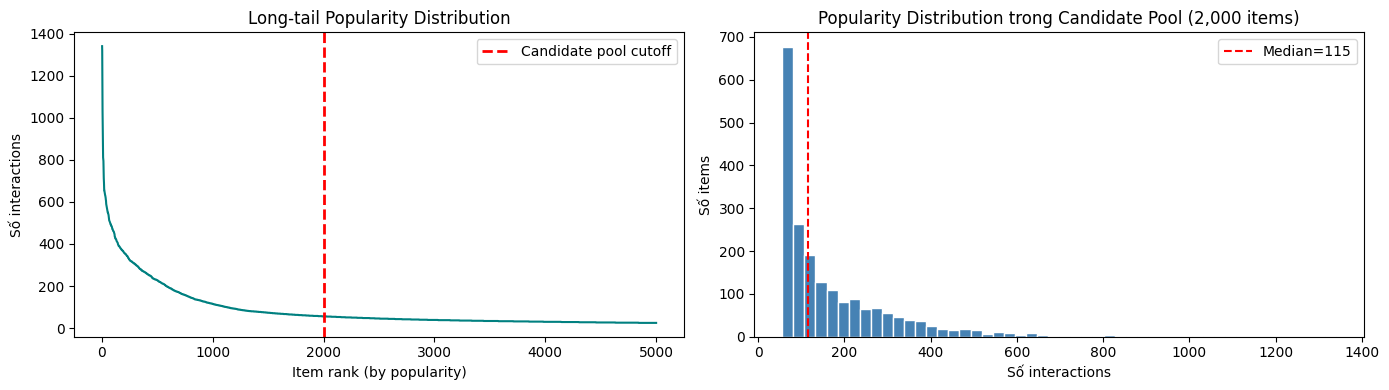

In [18]:
candidate_pool = list(item_counts_f.head(2000).index)
candidate_set  = set(candidate_pool)

print("POPULARITY DISTRIBUTION")
print(f"  Min interactions (top-2000) : {item_counts_f.head(2000).min()}")
print(f"  Max interactions            : {item_counts_f.max()}")
print(f"  Mean (top-2000)             : {item_counts_f.head(2000).mean():.1f}")
print(f"  Median (top-2000)           : {item_counts_f.head(2000).median():.1f}")

top1_pct  = item_counts_f.head(int(n_items_f * 0.01)).sum() / len(df_filtered) * 100
top10_pct = item_counts_f.head(int(n_items_f * 0.10)).sum() / len(df_filtered) * 100
print(f"\n  Long-tail effect:")
print(f"  Top 1%  items ({int(n_items_f*0.01):,} items) cover {top1_pct:.1f}% interactions")
print(f"  Top 10% items ({int(n_items_f*0.10):,} items) cover {top10_pct:.1f}% interactions")
print(f"  → Long-tail rõ ràng → Top-K popularity pool hợp lý cho DQN")

pool_counts = item_counts_f.head(2000)
gini_num = 2 * sum((i+1) * v for i, v in enumerate(sorted(pool_counts.values))) - (len(pool_counts) + 1) * pool_counts.sum()
gini = gini_num / (len(pool_counts) * pool_counts.sum())
print(f"\n  Gini coefficient (pool) : {gini:.3f}  (0=equal, 1=extreme skew)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, min(5001, n_items_f+1)), item_counts_f.head(5000).values, color="teal")
axes[0].axvline(2000, color="red", linestyle="--", linewidth=2, label="Candidate pool cutoff")
axes[0].set_xlabel("Item rank (by popularity)")
axes[0].set_ylabel("Số interactions")
axes[0].set_title("Long-tail Popularity Distribution")
axes[0].legend()

axes[1].hist(pool_counts.values, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(pool_counts.median(), color="red", linestyle="--", label=f"Median={pool_counts.median():.0f}")
axes[1].set_xlabel("Số interactions")
axes[1].set_ylabel("Số items")
axes[1].set_title("Popularity Distribution trong Candidate Pool (2,000 items)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. PHÂN TÍCH REWARD SPARSITY THEO TỪNG USER (REPLAY BUFFER)

REWARD SPARSITY PER USER
  Mean reward density  : 0.7237%
  Median               : 0.3500%
  Max                  : 39.1500%
  Min (non-zero)       : 0.0500%

  Phân bố reward density theo user:
  <0.1%        : 2,808 users (11.8%)
  0.1–0.5%     : 12,271 users (51.7%)
  0.5–1%       : 4,016 users (16.9%)
  1–5%         : 3,501 users (14.8%)
  >5%          : 394 users (1.7%)

  Avg positive interactions/user trong pool : 14.5 / 2000 items
  → Reward density ~0.7237% → rất sparse
  → DQN cần Replay Buffer lớn để có đủ positive samples

  Khuyến nghị Replay Buffer:
  buffer_size    = 50,000  (đủ để lưu nhiều episodes)
  batch_size     = 64      (stable gradient)
  min_replay     = 1,000   (warm-up trước khi train)


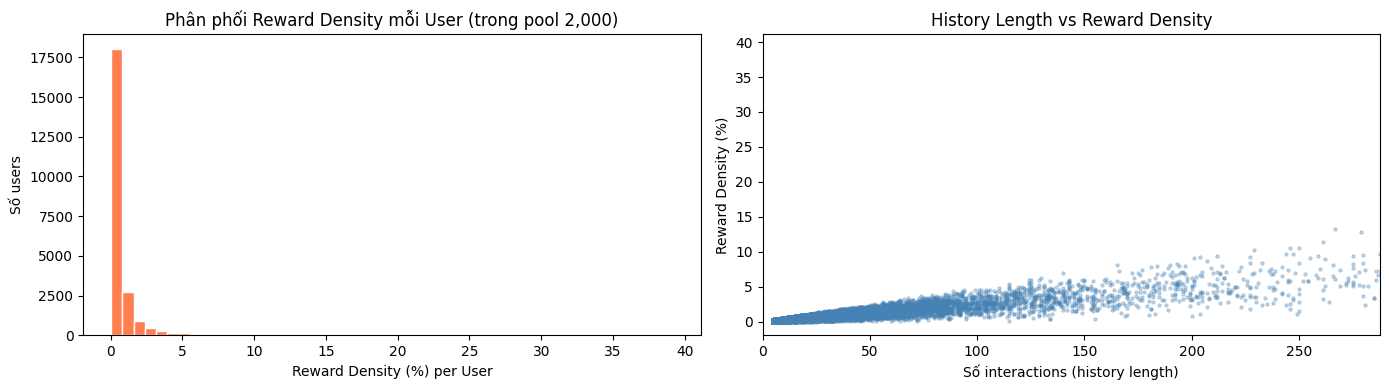

In [19]:
df_in_pool    = df_filtered[df_filtered["item_id"].isin(candidate_set)]
user_positive = df_in_pool.groupby("user_id").size()
user_hist_len = df_filtered.groupby("user_id").size()

user_reward_density = (user_positive / 2000).reindex(df_filtered["user_id"].unique(), fill_value=0)

print("REWARD SPARSITY PER USER")
print(f"  Mean reward density  : {user_reward_density.mean()*100:.4f}%")
print(f"  Median               : {user_reward_density.median()*100:.4f}%")
print(f"  Max                  : {user_reward_density.max()*100:.4f}%")
print(f"  Min (non-zero)       : {user_reward_density[user_reward_density > 0].min()*100:.4f}%")

bins   = [0, 0.001, 0.005, 0.01, 0.05, 1.0]
labels = ["<0.1%", "0.1–0.5%", "0.5–1%", "1–5%", ">5%"]
bucket = pd.cut(user_reward_density, bins=bins, labels=labels)
bucket_counts = bucket.value_counts().sort_index()
print("\n  Phân bố reward density theo user:")
for label, cnt in bucket_counts.items():
    print(f"  {label:<12} : {cnt:,} users ({cnt/len(user_reward_density)*100:.1f}%)")

avg_ep_len = user_hist_len.mean()
avg_pos_ep = user_positive.reindex(df_filtered["user_id"].unique(), fill_value=0).mean()
print(f"\n  Avg positive interactions/user trong pool : {avg_pos_ep:.1f} / 2000 items")
print(f"  → Reward density ~{avg_pos_ep/2000*100:.4f}% → rất sparse")
print(f"  → DQN cần Replay Buffer lớn để có đủ positive samples")
print("\n  Khuyến nghị Replay Buffer:")
print(f"  buffer_size    = 50,000  (đủ để lưu nhiều episodes)")
print(f"  batch_size     = 64      (stable gradient)")
print(f"  min_replay     = 1,000   (warm-up trước khi train)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_reward_density[user_reward_density > 0] * 100,
             bins=50, color="coral", edgecolor="white")
axes[0].set_xlabel("Reward Density (%) per User")
axes[0].set_ylabel("Số users")
axes[0].set_title("Phân phối Reward Density mỗi User (trong pool 2,000)")

x = user_hist_len.reindex(user_reward_density.index, fill_value=0)
axes[1].scatter(x, user_reward_density * 100, alpha=0.3, s=5, color="steelblue")
axes[1].set_xlabel("Số interactions (history length)")
axes[1].set_ylabel("Reward Density (%)")
axes[1].set_title("History Length vs Reward Density")
axes[1].set_xlim(0, x.quantile(0.99))

plt.tight_layout()
plt.show()

## TỔNG KẾT

In [20]:
pool_coverage = df_filtered[df_filtered["item_id"].isin(candidate_set)].shape[0] / len(df_filtered) * 100

print(f"Action space sau filter  : {n_items_f:,} items")
print(f"Candidate pool = 2,000   : cover {pool_coverage:.1f}% interactions")
print(f"Long-tail rõ ràng        : top 10% items cover phần lớn interactions")
print(f"Reward density trung bình: {user_reward_density.mean()*100:.4f}% → rất sparse")
print(f"\n  Config DQN đề xuất:")
print(f"  action_dim    = 2000    # candidate pool size")
print(f"  buffer_size   = 50000   # Replay Buffer")
print(f"  batch_size    = 64")
print(f"  epsilon_start = 0.5     # khám phá cao ban đầu vì reward sparse")
print(f"  epsilon_end   = 0.05")
print(f"  state_dim     = 512")

Action space sau filter  : 29,794 items
Candidate pool = 2,000   : cover 50.0% interactions
Long-tail rõ ràng        : top 10% items cover phần lớn interactions
Reward density trung bình: 0.7237% → rất sparse

  Config DQN đề xuất:
  action_dim    = 2000    # candidate pool size
  buffer_size   = 50000   # Replay Buffer
  batch_size    = 64
  epsilon_start = 0.5     # khám phá cao ban đầu vì reward sparse
  epsilon_end   = 0.05
  state_dim     = 512


# GIAI ĐOẠN 2 — TIỀN XỬ LÝ DỮ LIỆU CHUNG

## 1. PHÂN TÍCH KÍCH THƯỚC ACTION SPACE SAU FILTER

## CONFIG

In [21]:
CANDIDATE_POOL_SIZE = 2000
MIN_INTERACTIONS    = 5
TRAIN_RATIO         = 0.70
VAL_RATIO           = 0.15
PCA_DIM             = 512
K_HISTORY           = 5

APPRECIATE_PATH = '/kaggle/input/datasets/oanhkimnguyen/behance12/Behance_appreciate_1M/Behance_appreciate_1M.txt'
FEAT_PATH       = '/kaggle/input/datasets/oanhkimnguyen/behance-image-features/Behance_Image_Features.b'
SAVE_DIR        = '/kaggle/working/processed/'

os.makedirs(SAVE_DIR, exist_ok=True)

## BƯỚC 1 — LOAD DỮ LIỆU

In [22]:
df = pd.read_csv(
    APPRECIATE_PATH,
    sep=r'\s+',
    header=None,
    names=['user_id', 'item_id', 'timestamp']
)
print(f"Loaded: {df.shape}")

Loaded: (1000000, 3)


## BƯỚC 2 — 5-CORE FILTER

In [23]:
def apply_kcore(df, k=5, max_iter=20):
    for i in range(max_iter):
        before = len(df)
        user_cnt = df.groupby('user_id').size()
        item_cnt = df.groupby('item_id').size()
        df = df[
            df['user_id'].isin(user_cnt[user_cnt >= k].index) &
            df['item_id'].isin(item_cnt[item_cnt >= k].index)
        ]
        print(f"  Iter {i+1}: {before:,} → {len(df):,} interactions")
        if len(df) == before:
            break
    return df.reset_index(drop=True)

df = apply_kcore(df, k=MIN_INTERACTIONS)
print(f"Sau filter: {df['user_id'].nunique():,} users | {df['item_id'].nunique():,} items | {len(df):,} interactions")


  Iter 1: 1,000,000 → 712,271 interactions
  Iter 2: 712,271 → 692,212 interactions
  Iter 3: 692,212 → 687,768 interactions
  Iter 4: 687,768 → 687,246 interactions
  Iter 5: 687,246 → 687,094 interactions
  Iter 6: 687,094 → 687,078 interactions
  Iter 7: 687,078 → 687,070 interactions
  Iter 8: 687,070 → 687,070 interactions
Sau filter: 23,724 users | 29,794 items | 687,070 interactions


## BƯỚC 3 — MAP ID VỀ INDEX LIÊN TỤC

In [24]:
unique_users = sorted(df['user_id'].unique())
unique_items = sorted(df['item_id'].unique())

user2idx = {u: i for i, u in enumerate(unique_users)}
item2idx = {it: i for i, it in enumerate(unique_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

df['user_idx'] = df['user_id'].map(user2idx)
df['item_idx'] = df['item_id'].map(item2idx)

# Lưu mappings ra CSV
df_user_map = pd.DataFrame(list(user2idx.items()), columns=['user_id', 'user_idx'])
df_item_map = pd.DataFrame(list(item2idx.items()), columns=['item_id', 'item_idx'])
df_user_map.to_csv(SAVE_DIR + 'user_mappings.csv', index=False)
df_item_map.to_csv(SAVE_DIR + 'item_mappings.csv', index=False)

print(f"n_users={len(unique_users):,} | n_items={len(unique_items):,}")
print(f"Đã lưu user_mappings.csv, item_mappings.csv")

n_users=23,724 | n_items=29,794
Đã lưu user_mappings.csv, item_mappings.csv


## BƯỚC 4 — CHIA TRAIN / VAL / TEST THEO TIMESTAMP

In [25]:
df = df.sort_values('timestamp').reset_index(drop=True)

n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

df_train = df.iloc[:train_end].reset_index(drop=True)
df_val   = df.iloc[train_end:val_end].reset_index(drop=True)
df_test  = df.iloc[val_end:].reset_index(drop=True)

df_train.to_csv(SAVE_DIR + 'interactions_train.csv', index=False)
df_val.to_csv(SAVE_DIR + 'interactions_val.csv',   index=False)
df_test.to_csv(SAVE_DIR + 'interactions_test.csv',  index=False)

print(f"Train : {len(df_train):,} ({len(df_train)/n*100:.0f}%) | {pd.to_datetime(df_train['timestamp'].min(), unit='s').date()} → {pd.to_datetime(df_train['timestamp'].max(), unit='s').date()}")
print(f"Val : {len(df_val):,} ({len(df_val)/n*100:.0f}%)  | {pd.to_datetime(df_val['timestamp'].min(), unit='s').date()} → {pd.to_datetime(df_val['timestamp'].max(), unit='s').date()}")
print(f"Test : {len(df_test):,} ({len(df_test)/n*100:.0f}%)  | {pd.to_datetime(df_test['timestamp'].min(), unit='s').date()} → {pd.to_datetime(df_test['timestamp'].max(), unit='s').date()}")


Train : 480,948 (70%) | 2011-06-09 → 2011-10-06
Val : 103,061 (15%)  | 2011-10-06 → 2011-10-25
Test : 103,061 (15%)  | 2011-10-25 → 2011-11-14


## BƯỚC 5 — XÂY DỰNG USER HISTORY

In [26]:
user_gt_train = (
    df_train.groupby('user_idx')['item_idx']
    .apply(set)
    .to_dict()
)

item_popularity   = df_train.groupby('item_idx').size().sort_values(ascending=False)
candidate_pool_tmp = set(item_popularity.head(CANDIDATE_POOL_SIZE).index)

valid_users_final = {
    u for u, gt in user_gt_train.items()
    if len(gt & candidate_pool_tmp) > 0
}

user_history = (
    df_train[df_train['user_idx'].isin(valid_users_final)]
    .sort_values('timestamp')
    .groupby('user_idx')['item_idx']
    .apply(list)
    .reset_index()
)
user_history.columns = ['user_idx', 'history']

user_history['history'] = user_history['history'].apply(lambda x: ','.join(map(str, x)))
user_history.to_csv(SAVE_DIR + 'user_history.csv', index=False)

hist_lens = user_history['history'].apply(lambda x: len(x.split(',')))
print(f"{len(user_history):,} users có history (sau lọc GT in pool)")
print(f"Loại bỏ : {df_train['user_idx'].nunique() - len(user_history):,} users (no GT in pool)")
print(f"Mean history length : {hist_lens.mean():.1f}")
print(f"Median: {hist_lens.median():.1f}")
print(f"Min / Max : {hist_lens.min()} / {hist_lens.max()}")
print(f"Users đủ K={K_HISTORY}: {(hist_lens >= K_HISTORY).sum():,} ({(hist_lens >= K_HISTORY).mean()*100:.1f}%)")

19,684 users có history (sau lọc GT in pool)
Loại bỏ : 1,143 users (no GT in pool)
Mean history length : 24.2
Median: 10.0
Min / Max : 1 / 1264
Users đủ K=5: 17,235 (87.6%)


## BƯỚC 6 — XÂY DỰNG CANDIDATE POOL

In [27]:
item_popularity = df_train.groupby('item_idx').size().sort_values(ascending=False)
candidate_pool  = list(item_popularity.head(CANDIDATE_POOL_SIZE).index)

coverage = df_train[df_train['item_idx'].isin(candidate_pool)].shape[0] / len(df_train)

df_pool = pd.DataFrame({'item_idx': candidate_pool, 'rank': range(1, len(candidate_pool)+1)})
df_pool.to_csv(SAVE_DIR + 'candidate_pool.csv', index=False)

print(f"Candidate pool: {len(candidate_pool):,} items")
print(f"Coverage trong train: {coverage*100:.1f}% interactions")

Candidate pool: 2,000 items
Coverage trong train: 52.0% interactions


## BƯỚC 7 — XỬ LÝ IMAGE FEATURES

In [28]:
def load_image_features(filepath):
    features = {}
    with open(filepath, 'rb') as f:
        while True:
            raw_id = f.read(8)
            if len(raw_id) < 8:
                break
            item_id = raw_id.decode('ascii').strip('\x00')
            raw_feat = f.read(4096 * 4)
            if len(raw_feat) < 4096 * 4:
                break
            feat = struct.unpack('4096f', raw_feat)
            features[item_id] = np.array(feat, dtype=np.float32)
    return features

features_raw = load_image_features(FEAT_PATH)
print(f"Loaded {len(features_raw):,} image feature vectors")

feat_keys = [str(it).zfill(8) for it in unique_items]
feat_matrix = np.stack([features_raw[k] for k in feat_keys])
print(f"Feature matrix shape: {feat_matrix.shape}")

train_item_idxs = df_train['item_idx'].unique()        
feat_train_only  = feat_matrix[train_item_idxs]          

scaler = StandardScaler()
scaler.fit(feat_train_only)                            
feat_scaled = scaler.transform(feat_matrix)            

pca = PCA(n_components=PCA_DIM, random_state=42)
pca.fit(feat_scaled[train_item_idxs])                 
feat_pca = pca.transform(feat_scaled)                  

explained = pca.explained_variance_ratio_.sum()
print(f"PCA xong — giữ {explained*100:.1f}% variance (fit trên {len(train_item_idxs):,} train items)")

image_features_512 = {i: feat_pca[i].astype(np.float32) for i in range(len(unique_items))}

with open(SAVE_DIR + 'image_features_512.pkl', 'wb') as f:
    pickle.dump(image_features_512, f)
print(f"Đã lưu image_features_512.pkl — {len(image_features_512):,} items x {PCA_DIM}-dim")

Loaded 178,787 image feature vectors
Feature matrix shape: (29794, 4096)
PCA xong — giữ 75.7% variance (fit trên 26,835 train items)
Đã lưu image_features_512.pkl — 29,794 items x 512-dim


## TỔNG KẾT

In [29]:
print(f"interactions_train.csv — {len(df_train):,} rows")
print(f"interactions_val.csv   — {len(df_val):,} rows")
print(f"interactions_test.csv  — {len(df_test):,} rows")
print(f"user_history.csv       — {len(user_history):,} users")
print(f"candidate_pool.csv     — {len(candidate_pool):,} items")
print(f"user_mappings.csv      — {len(user2idx):,} users")
print(f"item_mappings.csv      — {len(item2idx):,} items")
print(f"image_features_512.pkl — {len(image_features_512):,} items x {PCA_DIM}-dim")

interactions_train.csv — 480,948 rows
interactions_val.csv   — 103,061 rows
interactions_test.csv  — 103,061 rows
user_history.csv       — 19,684 users
candidate_pool.csv     — 2,000 items
user_mappings.csv      — 23,724 users
item_mappings.csv      — 29,794 items
image_features_512.pkl — 29,794 items x 512-dim


# 2.2 Tiền Xử Lý Riêng A2C

## Lọc user theo độ dài trajectory

In [30]:
user_hist_len_train = df_train.groupby('user_idx').size()
valid_users_gte7    = set(user_hist_len_train[user_hist_len_train >= 7].index)

candidate_set_idx   = set(df_train.groupby('item_idx').size()
                          .sort_values(ascending=False).head(CANDIDATE_POOL_SIZE).index)

users_in_pool = set(df_train[df_train['item_idx'].isin(candidate_set_idx)]['user_idx'].unique())
valid_users   = valid_users_gte7 & users_in_pool

df_a2c = df_train[df_train['user_idx'].isin(valid_users)].copy() 

print(f"Users >= 7 interactions (train) : {len(valid_users_gte7):,}")
print(f"Users có trong pool (train)     : {len(users_in_pool):,}")
print(f"Users hợp lệ (giao)             : {len(valid_users):,}")
print(f"Interactions còn lại            : {len(df_a2c):,}")
print(f"Tỷ lệ giữ lại                   : {len(valid_users)/user_hist_len_train.shape[0]*100:.1f}%")

Users >= 7 interactions (train) : 14,112
Users có trong pool (train)     : 19,684
Users hợp lệ (giao)             : 13,876
Interactions còn lại            : 450,485
Tỷ lệ giữ lại                   : 66.6%


## Xây dựng trajectory theo thứ tự thời gian

In [31]:
df_a2c = df_a2c.sort_values(['user_idx', 'timestamp']).reset_index(drop=True)

trajectories = (
    df_a2c.groupby('user_idx')['item_idx']
    .apply(list)
    .reset_index()
    .rename(columns={'item_idx': 'trajectory'})
)

traj_len = trajectories['trajectory'].apply(len)
print(f"Trajectory trung bình : {traj_len.mean():.1f} steps")
print(f"Min / Max             : {traj_len.min()} / {traj_len.max()}")
print(f"Users có >= 7 steps   : {(traj_len >= 7).sum():,} ({(traj_len >= 7).mean()*100:.1f}%)")

Trajectory trung bình : 32.5 steps
Min / Max             : 7 / 1264
Users có >= 7 steps   : 13,876 (100.0%)


## Chia episode theo n_steps

In [32]:
N_STEPS = 7
STRIDE  = 3

def split_trajectory_to_episodes(traj, n_steps=N_STEPS, stride=STRIDE):
    episodes = []
    for start in range(0, len(traj) - n_steps + 1, stride):
        episodes.append(traj[start : start + n_steps])
    return episodes

trajectories['episodes'] = trajectories['trajectory'].apply(split_trajectory_to_episodes)
ep_counts      = trajectories['episodes'].apply(len)
total_episodes = ep_counts.sum()

print(f"n_steps              : {N_STEPS}")
print(f"stride               : {STRIDE}  (sliding window, tận dụng tối đa data)")
print(f"Tổng số episodes     : {total_episodes:,}")
print(f"Avg episodes/user    : {ep_counts.mean():.1f}")
print(f"Users có >= 1 episode: {(ep_counts >= 1).sum():,}")

n_steps              : 7
stride               : 3  (sliding window, tận dụng tối đa data)
Tổng số episodes     : 127,350
Avg episodes/user    : 9.2
Users có >= 1 episode: 13,876


## Lưu output A2C

In [33]:
trajectories['trajectory_str'] = trajectories['trajectory'].apply(
    lambda x: ','.join(map(str, x))
)

trajectories[['user_idx', 'trajectory_str']].rename(
    columns={'trajectory_str': 'trajectory'}
).to_csv(SAVE_DIR + 'trajectories_a2c.csv', index=False)

print(f"Saved: trajectories_a2c.csv  ({len(trajectories):,} users)")
print(f"\nConfig A2C xác nhận:")
print(f"  n_steps      = {N_STEPS}")
print(f"  state_dim    = 512")
print(f"  action_dim   = 2000")
print(f"  entropy_coef = 0.05")

Saved: trajectories_a2c.csv  (13,876 users)

Config A2C xác nhận:
  n_steps      = 7
  state_dim    = 512
  action_dim   = 2000
  entropy_coef = 0.05


# 2.2 Tiền Xử Lý Riêng DQN

## Xác nhận và lưu candidate pool

In [34]:
item_counts_train = df_train.groupby('item_idx').size().sort_values(ascending=False)
candidate_pool    = item_counts_train.head(CANDIDATE_POOL_SIZE).index.tolist()
candidate_set     = set(candidate_pool)

coverage = df_train[df_train['item_idx'].isin(candidate_set)].shape[0] / len(df_train)
print(f"Candidate pool size : {len(candidate_pool):,}")
print(f"Coverage (train)    : {coverage*100:.1f}%")
print(f"Min interactions    : {item_counts_train.head(CANDIDATE_POOL_SIZE).min()}")
print(f"Max interactions    : {item_counts_train.head(CANDIDATE_POOL_SIZE).max()}")

Candidate pool size : 2,000
Coverage (train)    : 52.0%
Min interactions    : 39
Max interactions    : 1192


## Lọc interactions trong candidate pool

In [35]:
valid_users_a2c = set(df_a2c['user_idx'].unique())

df_dqn = df_train[
    df_train['item_idx'].isin(candidate_set) &
    df_train['user_idx'].isin(valid_users_a2c)
].copy()

print(f"Interactions gốc (train)  : {len(df_train):,}")
print(f"Interactions trong pool   : {len(df_dqn):,}")
print(f"Users còn lại             : {df_dqn['user_idx'].nunique():,}")
print(f"Users A2C                 : {len(valid_users_a2c):,}")
print(f"Khớp users                : {'✓' if df_dqn['user_idx'].nunique() == len(valid_users_a2c) else '✗'}")

reward_density = len(df_dqn) / (df_dqn['user_idx'].nunique() * CANDIDATE_POOL_SIZE)
print(f"Reward density            : {reward_density*100:.4f}%")

Interactions gốc (train)  : 480,948
Interactions trong pool   : 234,280
Users còn lại             : 13,876
Users A2C                 : 13,876
Khớp users                : ✓
Reward density            : 0.8442%


## Xây dựng transitions (state, action, reward, next_state)

In [36]:
NEG_RATIO = 4  # 4 negative samples mỗi 1 positive → tỷ lệ 1:4

df_dqn_sorted = df_dqn.sort_values(['user_idx', 'timestamp']).reset_index(drop=True)
df_dqn_sorted['next_item_idx'] = df_dqn_sorted.groupby('user_idx')['item_idx'].shift(-1)
df_dqn_sorted['reward']        = 1

df_pos = df_dqn_sorted.dropna(subset=['next_item_idx']).copy()
df_pos['next_item_idx'] = df_pos['next_item_idx'].astype(int)

user_pos_items     = df_dqn.groupby('user_idx')['item_idx'].apply(set).to_dict()
candidate_pool_arr = np.array(candidate_pool)

# Precompute negative candidates cho mỗi unique user (thay vì tính lại mỗi row)
np.random.seed(42)
user_neg_pool = {
    uid: candidate_pool_arr[~np.isin(candidate_pool_arr, list(pos_set))]
    for uid, pos_set in user_pos_items.items()
}

user_idxs      = df_pos['user_idx'].values
next_item_idxs = df_pos['next_item_idx'].values
timestamps     = df_pos['timestamp'].values

neg_user_idx      = np.repeat(user_idxs, NEG_RATIO)
neg_next_item_idx = np.repeat(next_item_idxs, NEG_RATIO)
neg_timestamp     = np.repeat(timestamps, NEG_RATIO)

neg_item_idx = np.concatenate([
    np.random.choice(user_neg_pool[uid], size=min(NEG_RATIO, len(user_neg_pool[uid])), replace=False)
    if len(user_neg_pool.get(uid, [])) > 0
    else np.array([], dtype=int)
    for uid in user_idxs
])

df_neg = pd.DataFrame({
    'user_idx'     : neg_user_idx,
    'item_idx'     : neg_item_idx.astype(int),
    'reward'       : 0,
    'next_item_idx': neg_next_item_idx,
    'timestamp'    : neg_timestamp
})

df_transitions = pd.concat([
    df_pos[['user_idx', 'item_idx', 'reward', 'next_item_idx', 'timestamp']],
    df_neg
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

n_pos = (df_transitions['reward'] == 1).sum()
n_neg = (df_transitions['reward'] == 0).sum()
print(f"Positive transitions : {n_pos:,}  (reward=1)")
print(f"Negative transitions : {n_neg:,}  (reward=0)")
print(f"Tỷ lệ pos:neg        : 1:{n_neg/n_pos:.1f}")
print(f"Tổng transitions     : {len(df_transitions):,}")
print(f"Đủ fill buffer 50,000: {'✓' if len(df_transitions) >= 50000 else '✗'}")

Positive transitions : 220,404  (reward=1)
Negative transitions : 881,616  (reward=0)
Tỷ lệ pos:neg        : 1:4.0
Tổng transitions     : 1,102,020
Đủ fill buffer 50,000: ✓


## Lưu output DQN

In [37]:
with open(SAVE_DIR + 'candidate_pool_dqn.pkl', 'wb') as f:
    pickle.dump(candidate_pool, f)

transitions_path = SAVE_DIR + 'transitions_dqn.csv'
df_transitions.to_csv(transitions_path, index=False)

df_verify = pd.read_csv(transitions_path)
assert len(df_verify) == len(df_transitions),                           "Số dòng không khớp!"
assert set(df_verify.columns) == {'user_idx', 'item_idx', 'reward', 'next_item_idx', 'timestamp'}, "Cột không đúng!"
assert df_verify['reward'].isin([0, 1]).all(),                          "Reward phải là 0 hoặc 1!"

print(f"[OK] Saved: {SAVE_DIR}candidate_pool_dqn.pkl  ({len(candidate_pool):,} items)")
print(f"[OK] Saved: {transitions_path}")
print(f"     → {len(df_verify):,} rows | {(df_verify['reward']==1).sum():,} pos / {(df_verify['reward']==0).sum():,} neg")
print(f"\nConfig DQN xác nhận:")
print(f"  action_dim    = {CANDIDATE_POOL_SIZE}")
print(f"  buffer_size   = 50000")
print(f"  batch_size    = 64")
print(f"  epsilon_start = 0.5")
print(f"  epsilon_end   = 0.05")
print(f"  state_dim     = {PCA_DIM}")
print(f"  neg_ratio     = {NEG_RATIO}")

[OK] Saved: /kaggle/working/processed/candidate_pool_dqn.pkl  (2,000 items)
[OK] Saved: /kaggle/working/processed/transitions_dqn.csv
     → 1,102,020 rows | 220,404 pos / 881,616 neg

Config DQN xác nhận:
  action_dim    = 2000
  buffer_size   = 50000
  batch_size    = 64
  epsilon_start = 0.5
  epsilon_end   = 0.05
  state_dim     = 512
  neg_ratio     = 4


# Giai Đoạn 3 — Xây Dựng Môi Trường

In [38]:
SAVE_DIR             = '/kaggle/working/processed/'
FEATURES_PATH        = SAVE_DIR + 'image_features_512.pkl'
USER_HISTORY_PATH    = SAVE_DIR + 'user_history.csv'
CANDIDATE_POOL_PATH  = SAVE_DIR + 'candidate_pool.csv'
INTERACTIONS_PATH    = SAVE_DIR + 'interactions_train.csv'

# ── Config ──
STATE_DIM     = 512
K_HISTORY     = 5      
ACTION_DIM    = 2000   
REWARD_POS    = 1.0
REWARD_NEG    = 0.0

## Load dữ liệu môi trường

In [39]:
with open(FEATURES_PATH, 'rb') as f:
    image_features = pickle.load(f)

df_history = pd.read_csv(USER_HISTORY_PATH)
user_history = {
    row['user_idx']: list(map(int, row['history'].split(',')))
    for _, row in df_history.iterrows()
}

df_pool        = pd.read_csv(CANDIDATE_POOL_PATH)
candidate_pool = df_pool['item_idx'].tolist()
candidate_set  = set(candidate_pool)

df_train      = pd.read_csv(INTERACTIONS_PATH)
user_gt_train = df_train.groupby('user_idx')['item_idx'].apply(set).to_dict()

df_val        = pd.read_csv(SAVE_DIR + 'interactions_val.csv')
df_test       = pd.read_csv(SAVE_DIR + 'interactions_test.csv')
user_gt_eval  = (
    pd.concat([df_val, df_test])
    .groupby('user_idx')['item_idx']
    .apply(set)
    .to_dict()
)

user_gt = user_gt_train 

print(f"image_features  : {len(image_features):,} items x {STATE_DIM}-dim")
print(f"user_history    : {len(user_history):,} users")
print(f"candidate_pool  : {len(candidate_pool):,} items")
print(f"user_gt_train   : {len(user_gt_train):,} users")
print(f"user_gt_eval    : {len(user_gt_eval):,} users")

image_features  : 29,794 items x 512-dim
user_history    : 19,684 users
candidate_pool  : 2,000 items
user_gt_train   : 20,827 users
user_gt_eval    : 17,087 users


## State Representation

In [40]:
def get_state(user_idx: int,
              appreciated_so_far: list,
              user_history:   dict,
              image_features: dict,
              k_history: int = K_HISTORY,
              state_dim: int = STATE_DIM) -> np.ndarray:
    """
    Tính state vector từ K items gần nhất user đã appreciate.
    Dùng exponential weighted average: item càng gần nhất càng được trọng số cao hơn.
    """
    recent = (
        appreciated_so_far[-k_history:]
        if len(appreciated_so_far) >= k_history
        else (user_history.get(user_idx, [])[-k_history:] + appreciated_so_far)[-k_history:]
    )

    if len(recent) == 0:
        return np.zeros(state_dim, dtype=np.float32)

    vecs = [image_features[i] for i in recent if i in image_features]
    if len(vecs) == 0:
        return np.zeros(state_dim, dtype=np.float32)

    weights = np.exp(np.arange(len(vecs), dtype=np.float32))
    weights /= weights.sum()

    return np.average(vecs, axis=0, weights=weights).astype(np.float32)

## BehanceEnvironment

In [44]:
class BehanceEnvironment:
    def __init__(self,
                 user_gt:        dict,
                 user_history:   dict,
                 candidate_pool: list,
                 image_features: dict,
                 max_steps:      int = 50):
        self.user_gt        = user_gt
        self.user_history   = user_history
        self.candidate_pool = candidate_pool
        self.candidate_set  = set(candidate_pool)
        self.image_features = image_features
        self.max_steps      = max_steps

        self._user_idx    = None
        self._step_count  = 0
        self._appreciated = []
        self._recommended = set()
        self._gt_in_pool  = set()

        self._valid_users = [
            u for u in self.user_gt
            if u in self.user_history
            and len(self.user_gt[u] & self.candidate_set) > 0
        ]

    def _get_state(self, user_idx: int, appreciated_so_far: list) -> np.ndarray:
        """Wrapper nội bộ — truyền user_history và image_features từ self."""
        return get_state(user_idx, appreciated_so_far,
                         self.user_history, self.image_features)

    def reset(self, user_idx: int) -> np.ndarray:
        self._user_idx    = user_idx
        self._step_count  = 0
        self._appreciated = list(self.user_history.get(user_idx, []))
        self._recommended = set()
        self._gt_in_pool  = self.user_gt.get(user_idx, set()) & self.candidate_set
        return self._get_state(user_idx, self._appreciated)  # ← dùng _get_state

    def step(self, action: int):
        assert action in self.candidate_set, f"action {action} không thuộc candidate pool"

        gt = self.user_gt.get(self._user_idx, set())

        if action in gt and action not in self._recommended:
            reward = REWARD_POS
            self._appreciated.append(action)
        else:
            reward = REWARD_NEG

        self._recommended.add(action)
        self._step_count += 1

        next_state = self._get_state(self._user_idx, self._appreciated)  # ← dùng _get_state

        found_all_gt = self._gt_in_pool.issubset(self._recommended)
        done = (self._step_count >= self.max_steps) or \
               (len(self._recommended) >= len(self.candidate_pool)) or \
               found_all_gt

        return next_state, reward, done

    def get_valid_users(self) -> list:
        return self._valid_users

    def sample_user(self) -> int:
        return random.choice(self._valid_users)

## Khởi tạo môi trường

In [45]:
env = BehanceEnvironment(
    user_gt        = user_gt,
    user_history   = user_history,
    candidate_pool = candidate_pool,
    image_features = image_features,
    max_steps      = 50
)

valid_users = env.get_valid_users()
print(f"Valid users : {len(valid_users):,}")
print(f"State dim   : {STATE_DIM}")
print(f"Action dim  : {ACTION_DIM}")
print(f"Max steps   : {env.max_steps}")

Valid users : 19,684
State dim   : 512
Action dim  : 2000
Max steps   : 50


## Sanity Check môi trường

In [46]:
import random
import numpy as np

np.random.seed(42)
random.seed(42)
N_EPISODES = 100

test_user  = valid_users[0]
gt_in_pool = user_gt.get(test_user, set()) & candidate_set

state = env.reset(test_user)
print("=== STATE CHECK ===")
print(f"User idx         : {test_user}")
print(f"GT items in pool : {len(gt_in_pool)}")
print(f"State shape      : {state.shape}  (expected: ({STATE_DIM},))")
print(f"State dtype      : {state.dtype}")
print(f"State norm       : {np.linalg.norm(state):.4f}  (0.0 = không có history)")

print("\nREWARD & NEXT STATE CHECK")
env.reset(test_user)
gt_item    = list(gt_in_pool)[0]
state_before = env.reset(test_user)
next_state_gt, reward_gt, _ = env.step(gt_item)
state_changed = not np.allclose(state_before, next_state_gt)
print(f"GT item reward          : {reward_gt}  (expected: 1.0)")
print(f"State thay đổi sau +1   : {'Có' if state_changed else 'Không — sliding window bị lỗi'}")

non_gt         = [x for x in candidate_pool if x not in gt_in_pool][0]
state_before2  = env.reset(test_user)
next_state_non, reward_non, _ = env.step(non_gt)
state_unchanged = np.allclose(state_before2, next_state_non)
print(f"Non-GT item reward      : {reward_non}  (expected: 0.0)")
print(f"State không đổi khi r=0 : {'✅ Đúng' if state_unchanged else '⚠️ Thay đổi — kiểm tra lại'}")

print("\n=== DONE CONDITION CHECK ===")
env.reset(test_user)
for item in list(gt_in_pool):         
    _, _, done = env.step(item)
print(f"Done sau khi hết GT     : {'True' if done else 'False — found_all_gt không hoạt động'}")

print(f"\nRANDOM POLICY ({N_EPISODES} episodes)")
episode_rewards, episode_steps = [], []
for _ in range(N_EPISODES):
    env.reset(test_user)
    total_reward, step = 0, 0
    while True:
        action = random.choice(candidate_pool)
        _, reward, done = env.step(action)
        total_reward += reward
        step += 1
        if done:
            break
    episode_rewards.append(total_reward)
    episode_steps.append(step)

empirical   = np.mean(episode_rewards) / np.mean(episode_steps)
theoretical = len(gt_in_pool) / ACTION_DIM
print(f"Steps/episode           : {np.mean(episode_steps):.1f}")
print(f"Mean reward/episode     : {np.mean(episode_rewards):.2f}")
print(f"Empirical hit rate      : {empirical*100:.4f}%")
print(f"Theoretical hit rate    : {theoretical*100:.4f}%")
print(f"Ratio (exp ≈ 1.0)       : {empirical/theoretical:.2f}")
print(f"Episodes reward = 0     : {sum(r == 0 for r in episode_rewards)}/{N_EPISODES}")

assert state.shape         == (STATE_DIM,), "State dim sai!"
assert next_state_gt.shape == (STATE_DIM,), "Next state dim sai!"
assert reward_gt           == 1.0,          "GT item phải reward = 1!"
assert reward_non          == 0.0,          "Non-GT item phải reward = 0!"
assert state_changed,                       "State phải thay đổi sau khi appreciate item mới!"


=== STATE CHECK ===
User idx         : 0
GT items in pool : 19
State shape      : (512,)  (expected: (512,))
State dtype      : float32
State norm       : 25.1203  (0.0 = không có history)

REWARD & NEXT STATE CHECK
GT item reward          : 1.0  (expected: 1.0)
State thay đổi sau +1   : Có
Non-GT item reward      : 0.0  (expected: 0.0)
State không đổi khi r=0 : ✅ Đúng

=== DONE CONDITION CHECK ===
Done sau khi hết GT     : True

RANDOM POLICY (100 episodes)
Steps/episode           : 50.0
Mean reward/episode     : 0.45
Empirical hit rate      : 0.9000%
Theoretical hit rate    : 0.9500%
Ratio (exp ≈ 1.0)       : 0.95
Episodes reward = 0     : 64/100


## Tổng kết môi trường

In [47]:
gt_sizes = [len(v & candidate_set) for v in user_gt.values()]
gt_sizes = [x for x in gt_sizes if x > 0]

print("ENVIRONMENT SUMMARY")
print(f"  Valid users          : {len(valid_users):,}")
print(f"  State dim            : {STATE_DIM}")
print(f"  Action dim           : {ACTION_DIM}")
print(f"  Max steps/episode    : {env.max_steps}")
print(f"  K history            : {K_HISTORY}")
print(f"\n  Ground truth trong pool:")
print(f"    Mean GT/user       : {np.mean(gt_sizes):.1f} items")
print(f"    Median GT/user     : {np.median(gt_sizes):.1f} items")
print(f"    Random hit rate    : {np.mean(gt_sizes)/ACTION_DIM*100:.4f}%")
print(f"\n  Config xác nhận:")
print(f"    state_dim          = {STATE_DIM}")
print(f"    action_dim         = {ACTION_DIM}")
print(f"    reward             = binary (0/1)")
print(f"    k_history          = {K_HISTORY}")
print(f"    max_steps          = {env.max_steps}")

ENVIRONMENT SUMMARY
  Valid users          : 19,684
  State dim            : 512
  Action dim           : 2000
  Max steps/episode    : 50
  K history            : 5

  Ground truth trong pool:
    Mean GT/user       : 12.7 items
    Median GT/user     : 6.0 items
    Random hit rate    : 0.6356%

  Config xác nhận:
    state_dim          = 512
    action_dim         = 2000
    reward             = binary (0/1)
    k_history          = 5
    max_steps          = 50
